### Nome: Arthur Felipe Reis Souza, Matrícula: 2021013884.
### Nome: Salvador Cândido da Silva Júnior, Matrícula: 2020007015

In [1]:
%pwd

'/home/salvadorcsj/FINAL_PROJECT_ML'

In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip list

Package                 Version
----------------------- -----------
asttokens               3.0.1
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
executing               2.2.1
fonttools               4.60.1
imbalanced-learn        0.14.0
imblearn                0.0
ipykernel               7.1.0
ipython                 9.7.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.2
jupyter_client          8.6.3
jupyter_core            5.9.1
kiwisolver              1.4.9
matplotlib              3.10.7
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.3.5
packaging               25.0
pandas                  2.3.3
parso                   0.8.5
pexpect                 4.9.0
pillow                  12.0.0
pip                     24.0
platformdirs            4.5.0
prompt_toolkit          3.0.52
psutil                  7.1.

In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

# 1- Analyzing and pre-processing the data:

### 1.1 - Opening the file an reading it, and making a general analysis.

In [5]:
# taking the path of the files and opening them
folder_data='/home/salvadorcsj/FINAL_PROJECT_ML/data/'
files=os.listdir(folder_data)
print(f"The files inside the folder are: {files}")

The files inside the folder are: ['df_test_encoded.csv', 'df_test.csv', 'df_train_encoded.csv', 'df_train.csv']


In [6]:
df_train = pd.read_csv(os.path.join(folder_data, 'df_train.csv'))

In [7]:
df_train.head()

,id,garden_points_status,commitment_months,participation_history,project_focus_code,requested_resources_value,personal_reserve_status,volunteer_tenure_bracket,time_commitment_rate,household_profile,...,asset_contribution_type,member_age,other_support_plans,housing_situation,existing_commitments_count,role_skill_tier,dependents_supported,has_phone,newcomer_status,support_outcome
0,829,Points negative,36.0,Previous roles completed,Transport (used),8335.0,No reserve,>=7,3.0,Single adult,...,No tangible assets,47.0,NaN,Hosted / no rent,1.0,Skilled volunteer,1.0,No phone,Newcomer,bad
1,998,No points account,12.0,Previous roles completed,Communications equipment,804.0,Reserve: <100,>=7,4.0,Single adult,...,Shared tools,38.0,NaN,Own housing,1.0,Skilled volunteer,1.0,No phone,Newcomer,good
2,149,Points negative,36.0,Issues on prior roles,Workshop equipment,5371.0,Reserve: <100,1<=X<4,3.0,Single adult,...,Long-term fund,28.0,NaN,Own housing,2.0,Skilled volunteer,1.0,No phone,Newcomer,good
3,736,Points 0–199,36.0,All roles on time,Shared appliances,3990.0,No reserve,<1,3.0,Adult w/ dependents or shared household,...,No tangible assets,29.0,Partner bank,Own housing,1.0,Unemployed / non-resident unskilled,1.0,No phone,Newcomer,good
4,131,Points 0–199,48.0,Previous roles completed,Transport (new),8487.0,No reserve,4<=X<7,1.0,Adult w/ dependents or shared household,...,Shared tools,24.0,NaN,Own housing,1.0,Skilled volunteer,1.0,No phone,Newcomer,good


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             800 non-null    int64  
 1   garden_points_status           800 non-null    object 
 2   commitment_months              800 non-null    float64
 3   participation_history          800 non-null    object 
 4   project_focus_code             800 non-null    object 
 5   requested_resources_value      800 non-null    float64
 6   personal_reserve_status        800 non-null    object 
 7   volunteer_tenure_bracket       800 non-null    object 
 8   time_commitment_rate           800 non-null    float64
 9   household_profile              800 non-null    object 
 10  co_sponsor_presence            800 non-null    object 
 11  years_in_neighborhood_bracket  800 non-null    float64
 12  asset_contribution_type        800 non-null    obj

In [9]:
# Counting the number of NaN values in each column of the training dataset
for column in df_train.columns:
    num_missing = df_train[column].isna().sum()
    print(f"Column '{column}' has {num_missing} missing values.")

Column 'id' has 0 missing values.
Column 'garden_points_status' has 0 missing values.
Column 'commitment_months' has 0 missing values.
Column 'participation_history' has 0 missing values.
Column 'project_focus_code' has 0 missing values.
Column 'requested_resources_value' has 0 missing values.
Column 'personal_reserve_status' has 0 missing values.
Column 'volunteer_tenure_bracket' has 0 missing values.
Column 'time_commitment_rate' has 0 missing values.
Column 'household_profile' has 0 missing values.
Column 'co_sponsor_presence' has 0 missing values.
Column 'years_in_neighborhood_bracket' has 0 missing values.
Column 'asset_contribution_type' has 0 missing values.
Column 'member_age' has 0 missing values.
Column 'other_support_plans' has 649 missing values.
Column 'housing_situation' has 0 missing values.
Column 'existing_commitments_count' has 0 missing values.
Column 'role_skill_tier' has 0 missing values.
Column 'dependents_supported' has 0 missing values.
Column 'has_phone' has 0 

### 1.2 - In the analysis, We noted the high number of missing values in the column other_support_plans, then We investigated it more:

In [10]:
# Excluding the column other_support_plans due to high number of missing values (649/800)=~81%
df_train['other_support_plans'].value_counts()
print(f"The percentage of NaN values was: {df_train['other_support_plans'].isna().sum()/len(df_train)*100:.2f}%")
df_train = df_train.drop(columns=['other_support_plans'])

The percentage of NaN values was: 81.12%


In [11]:
x_train = df_train.drop(columns=['support_outcome'])
y_train = df_train['support_outcome']

### 1.3 - Splitting the dataset into value-labels:

In [12]:
# Splitting the data into features and target variable
x_train = df_train.drop(columns=['support_outcome'])
y_train = df_train['support_outcome']

### 1.4 - Verifying if this is a balanced dataset:

In [13]:
# Verifying if is a balanced dataset
y_train.value_counts(normalize=False)
print(f"The dataset is imbalanced since there are more 'good' outcomes than 'bad' ones.")
print(f"The proportion of 'good' outcomes is {y_train.value_counts(normalize=True)['good']:.1%} and 'bad' outcomes is {y_train.value_counts(normalize=True)['bad']:.1%}.")

The dataset is imbalanced since there are more 'good' outcomes than 'bad' ones.
The proportion of 'good' outcomes is 70.0% and 'bad' outcomes is 30.0%.


In [14]:
# Verifying if there are duplicate rows in the training dataset
num_duplicates = df_train.duplicated().sum()
print(f"The number of duplicate rows in the training dataset is: {num_duplicates}")

The number of duplicate rows in the training dataset is: 0


### 1.4 - Transforming the categories columns into useful information:

In [15]:
# Identifying categorical and numerical columns
categorical_cols = x_train.select_dtypes(include=['object']).columns
numerical_cols = x_train.select_dtypes(include=[np.number]).columns
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Categorical columns: Index(['garden_points_status', 'participation_history', 'project_focus_code',
       'personal_reserve_status', 'volunteer_tenure_bracket',
       'household_profile', 'co_sponsor_presence', 'asset_contribution_type',
       'housing_situation', 'role_skill_tier', 'has_phone', 'newcomer_status'],
      dtype='object')
Numerical columns: Index(['id', 'commitment_months', 'requested_resources_value',
       'time_commitment_rate', 'years_in_neighborhood_bracket', 'member_age',
       'existing_commitments_count', 'dependents_supported'],
      dtype='object')


In [16]:
# counting the number of categories for each categorical column
for col in categorical_cols:
    num_categories = x_train[col].nunique()
    print(f"Column '{col}' has {num_categories} unique categories.")
    print(f"The categories are: {df_train[col].unique()}\n")

Column 'garden_points_status' has 4 unique categories.
The categories are: ['Points negative' 'No points account' 'Points 0–199' 'Points 200+']

Column 'participation_history' has 5 unique categories.
The categories are: ['Previous roles completed' 'Issues on prior roles' 'All roles on time'
 'No prior roles / all on time' 'Delayed in prior commitments']

Column 'project_focus_code' has 10 unique categories.
The categories are: ['Transport (used)' 'Communications equipment' 'Workshop equipment'
 'Shared appliances' 'Transport (new)' 'Training / education' 'Retraining'
 'Plot repairs' 'Other project' 'Microenterprise support']

Column 'personal_reserve_status' has 5 unique categories.
The categories are: ['No reserve' 'Reserve: <100' 'Reserve: 100–499' 'Reserve: ≥1000'
 'Reserve: 500–999']

Column 'volunteer_tenure_bracket' has 5 unique categories.
The categories are: ['>=7' '1<=X<4' '<1' '4<=X<7' 'unemployed']

Column 'household_profile' has 4 unique categories.
The categories are: ['S

In [17]:
ordinal_cols = [
    'garden_points_status', 
    'personal_reserve_status', 
    'role_skill_tier'
]

# Define the specific order for each feature
garden_points_categories = ['Points negative', 'No points account', 'Points 0–199', 'Points 200+']
personal_reserve_categories = ['No reserve', 'Reserve: <100', 'Reserve: 100–499', 'Reserve: 500–999', 'Reserve: ≥1000']
role_skill_categories = ['Unemployed / non-resident unskilled', 'Unskilled resident', 'Skilled volunteer', 'Highly skilled / lead']
# Note: I'm treating 'unemployed' in volunteer_tenure_bracket as nominal, so I'll leave it for OHE.

# 2. Define your nominal (one-hot) features
# All remaining 'object' columns that are not ordinal
nominal_cols = [
    'participation_history', 'project_focus_code', 'volunteer_tenure_bracket', 
    'household_profile', 'co_sponsor_presence', 'asset_contribution_type',
    'housing_situation', 'has_phone', 'newcomer_status'
]

# 3. Define your numerical features (remove 'id')
numerical_cols = [
    'commitment_months', 'requested_resources_value', 'time_commitment_rate', 
    'years_in_neighborhood_bracket', 'member_age', 'existing_commitments_count', 
    'dependents_supported'
]

In [18]:
# 4. Create the ColumnTransformer
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[
            garden_points_categories, 
            personal_reserve_categories, 
            role_skill_categories
        ]), ordinal_cols),
        
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        
        ('numeric', 'passthrough', numerical_cols)
    ],
    remainder='drop' # Drops the 'id' column and any others not specified
)

In [19]:
# 5. Applying the new preprocessing OHE:
x_train_processed = preprocessor_tree.fit_transform(x_train)
x_train_processed

array([[ 0.,  0.,  2., ..., 47.,  1.,  1.],
       [ 1.,  1.,  2., ..., 38.,  1.,  1.],
       [ 0.,  1.,  2., ..., 28.,  2.,  1.],
       ...,
       [ 1.,  1.,  2., ..., 43.,  1.,  1.],
       [ 0.,  0.,  2., ..., 23.,  2.,  1.],
       [ 1.,  1.,  2., ..., 33.,  1.,  1.]], shape=(800, 48))

In [20]:
# Get the new feature names for the tree plot
ohe_feature_names = preprocessor_tree.named_transformers_['onehot'].get_feature_names_out(nominal_cols)
all_feature_names = ordinal_cols + list(ohe_feature_names) + numerical_cols

In [21]:
# Create the processed DataFrame
df_train_encoded = pd.DataFrame(x_train_processed, columns=all_feature_names, index=x_train.index)

# You'll also need to transform x_test for submission

print("New processed training data shape:", df_train_encoded.shape)
df_train_encoded.head()

New processed training data shape: (800, 48)


,garden_points_status,personal_reserve_status,role_skill_tier,participation_history_All roles on time,participation_history_Delayed in prior commitments,participation_history_Issues on prior roles,participation_history_No prior roles / all on time,participation_history_Previous roles completed,project_focus_code_Communications equipment,project_focus_code_Microenterprise support,...,has_phone_No phone,newcomer_status_Local resident,newcomer_status_Newcomer,commitment_months,requested_resources_value,time_commitment_rate,years_in_neighborhood_bracket,member_age,existing_commitments_count,dependents_supported
0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,36.0,8335.0,3.0,4.0,47.0,1.0,1.0
1,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,12.0,804.0,4.0,4.0,38.0,1.0,1.0
2,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,5371.0,3.0,2.0,28.0,2.0,1.0
3,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,3990.0,3.0,2.0,29.0,1.0,1.0
4,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,48.0,8487.0,1.0,2.0,24.0,1.0,1.0


In [22]:
df_train_encoded

,garden_points_status,personal_reserve_status,role_skill_tier,participation_history_All roles on time,participation_history_Delayed in prior commitments,participation_history_Issues on prior roles,participation_history_No prior roles / all on time,participation_history_Previous roles completed,project_focus_code_Communications equipment,project_focus_code_Microenterprise support,...,has_phone_No phone,newcomer_status_Local resident,newcomer_status_Newcomer,commitment_months,requested_resources_value,time_commitment_rate,years_in_neighborhood_bracket,member_age,existing_commitments_count,dependents_supported
0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,36.0,8335.0,3.0,4.0,47.0,1.0,1.0
1,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,12.0,804.0,4.0,4.0,38.0,1.0,1.0
2,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,5371.0,3.0,2.0,28.0,2.0,1.0
3,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,3990.0,3.0,2.0,29.0,1.0,1.0
4,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,48.0,8487.0,1.0,2.0,24.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,6.0,1237.0,1.0,1.0,27.0,2.0,1.0
796,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,24.0,1333.0,4.0,2.0,43.0,2.0,2.0
797,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,18.0,2515.0,3.0,4.0,43.0,1.0,1.0
798,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,18.0,8471.0,1.0,2.0,23.0,2.0,1.0


In [23]:
# verifying if there's a categorical
for col in df_train_encoded.columns:
    if df_train_encoded[col].dtype == 'object':
        print(f"Categorical column found: {col}")

In [24]:
# Encoding good to 1 and bad to 0
y_train = y_train.map({'good': 1, 'bad': 0})

### 1.5 - Analysing the correlation between the columns

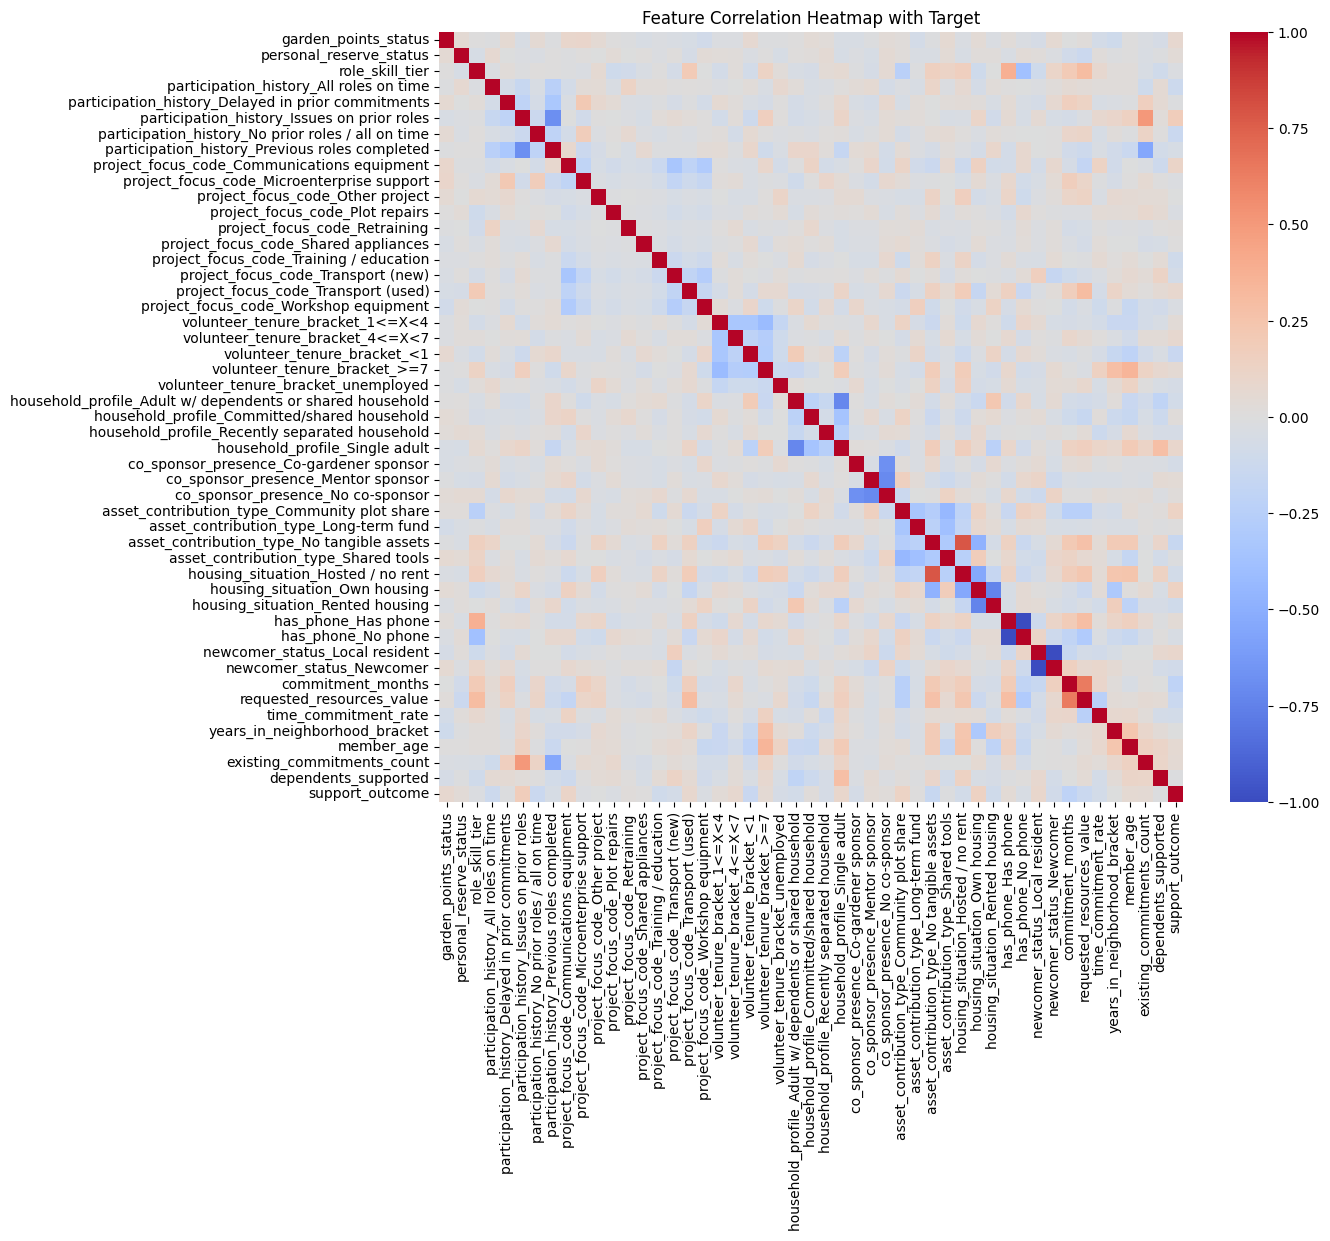

In [25]:
corr_analysis = df_train_encoded.copy()
corr_analysis['support_outcome'] = y_train
# Plotting the correlation heatmap with the label y included:
plt.figure(figsize=(12, 10))
correlation_matrix = corr_analysis.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', cbar=True)
plt.title('Feature Correlation Heatmap with Target')
plt.show()

### 1.6 - Spliting the dataset in training and test datasets

In [26]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    df_train_encoded, y_train, test_size=0.2, random_state=42, stratify=y_train)

# 2 - Applying algorithms in the processed dataset:

### 2.0 - Utility functions

In [27]:
def create_and_plot_confusion_matrix(y_test, y_pred, classifier_name, cmap_color):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_color, cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.savefig(f'results/{classifier_name}_confusion_matrix.png')
    plt.show()
    return cm

def create_roc_curve(classifier_name, y_val_prob, y_val_split, line_color):
    fpr, tpr, thresholds = roc_curve(y_val_split, y_val_prob)
    roc_auc_dt = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color=line_color, lw=2, label=f'ROC curve (AUC = {roc_auc_dt:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{classifier_name} Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.savefig(f'results/{classifier_name}_roc_curve.png')
    plt.show()

### 2.1 - Applying Decision Trees:

In [28]:
# Using a cross-validation to find the results from our tree:
dt_classifier = DecisionTreeClassifier(random_state=42)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_classifier, X_train_split, y_train_split, cv=kf, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean()}")
accuracy_dt = cv_scores.mean()

Cross-validation accuracy scores: [0.640625 0.6875   0.6875   0.640625 0.703125]
Mean cross-validation accuracy: 0.671875


In [29]:
# Using a grid-search to find the best hyperparameters for DecisionTreeClassifier
param_grid = {
    'max_depth': [5, 10, 20, 30, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up the grid search
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_split, y_train_split)

# Output the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)
print("Model training and evaluation complete.")

Best parameters found:  {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score:  0.703125
Model training and evaluation complete.


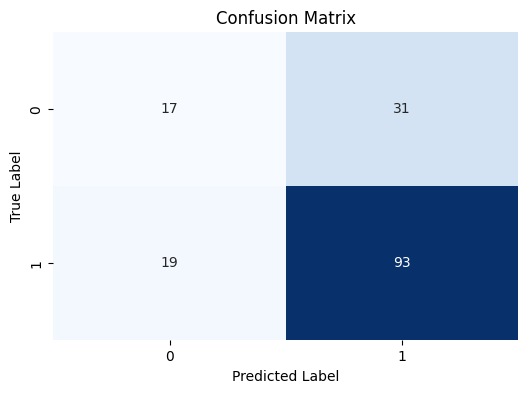

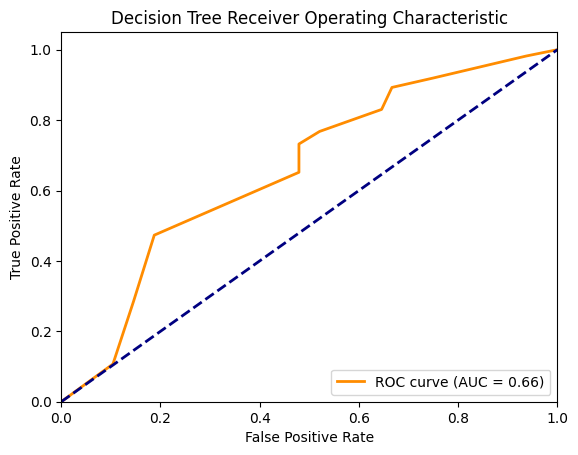

In [30]:
# Creating a confusion matrix:
best_dt_classifier = DecisionTreeClassifier(random_state=42, **grid_search.best_params_)
best_dt_classifier.fit(X_train_split, y_train_split)
y_val_pred = best_dt_classifier.predict(X_val_split)
dt_best_hyperparameters = grid_search.best_params_
cm = create_and_plot_confusion_matrix(y_val_split, y_val_pred, 'Decision Tree', 'Blues')

# Creating the ROC curve:
y_val_prob = best_dt_classifier.predict_proba(X_val_split)[:, 1]
create_roc_curve('Decision Tree', y_val_prob, y_val_split, 'darkorange')

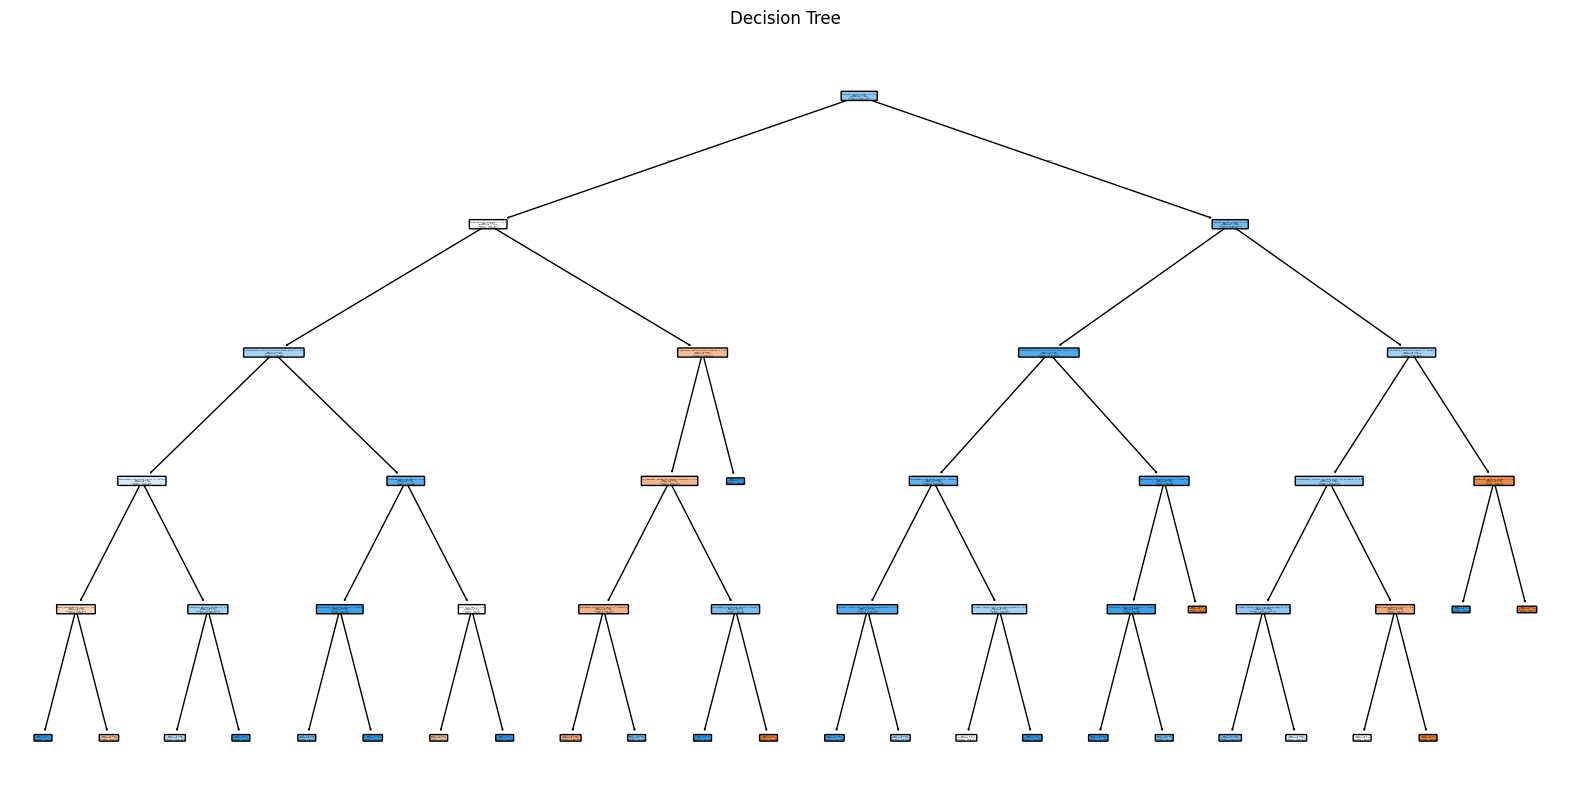

In [31]:
# Plotting the tree
plt.figure(figsize=(20, 10))
plot_tree(best_dt_classifier, filled=True, feature_names=df_train_encoded.columns, class_names=['bad', 'good'], rounded=True)
plt.title('Decision Tree')
plt.show()

### 2.2 -  Applying Random Forest:

In [32]:
# Creating a random forest classifier with grid-search cross-validation
rf_classifier = RandomForestClassifier(random_state=42)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_classifier, X_train_split, y_train_split, cv=kf, scoring='accuracy')

print(f"Random Forest Cross-validation accuracy scores: {cv_scores_rf}")
print(f"Mean cross-validation accuracy: {cv_scores_rf.mean()}")
accuracy_rf = cv_scores_rf.mean()

Random Forest Cross-validation accuracy scores: [0.734375  0.6953125 0.7890625 0.71875   0.765625 ]
Mean cross-validation accuracy: 0.740625


In [33]:
# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt', 0.5, 0.7]
}

# Set up the grid search
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid_rf, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train_split, y_train_split)

# Output the best parameters and best score
print("Best parameters found: ", grid_search_rf.best_params_)
print("Best cross-validation score: ", grid_search_rf.best_score_)

Best parameters found:  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score:  0.74375


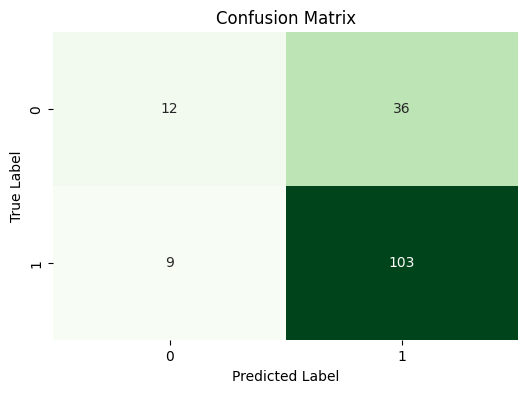

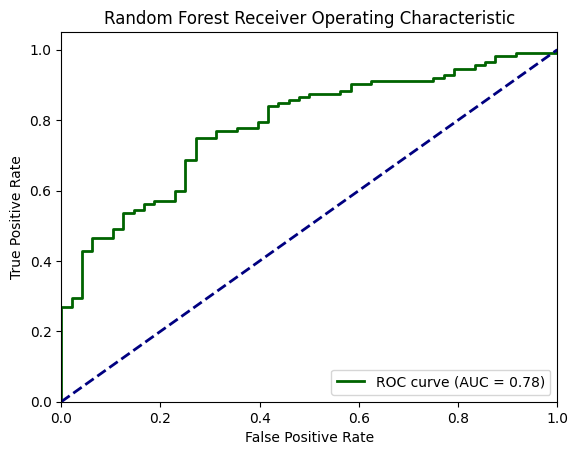

In [34]:
# Plotting the confusion matrix for Random Forest
best_rf_classifier = RandomForestClassifier(random_state=42, **grid_search_rf.best_params_)
best_rf_classifier.fit(X_train_split, y_train_split)
y_val_pred_rf = best_rf_classifier.predict(X_val_split)
rf_best_hyperparameters = grid_search_rf.best_params_
cm_rf = create_and_plot_confusion_matrix(y_val_split, y_val_pred_rf, 'Random Forest', 'Greens')

# Plotting the ROC curve
y_val_prob_rf = best_rf_classifier.predict_proba(X_val_split)[:, 1]
create_roc_curve('Random Forest', y_val_prob_rf, y_val_split, 'darkgreen')

### 2.3 -  Applying Gradient Boosting: 

In [35]:
# Using Gradient Boosting with cross-validation to test the results:
gb_classifier = GradientBoostingClassifier(random_state=42)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_gb = cross_val_score(gb_classifier, X_train_split, y_train_split, cv=kf, scoring='accuracy')

print(f"Gradient Boosting Cross-validation accuracy scores: {cv_scores_gb}")
print(cv_scores_gb.mean())
accuracy_gb = cv_scores_gb.mean()

Gradient Boosting Cross-validation accuracy scores: [0.75      0.7265625 0.78125   0.703125  0.7265625]
0.7375


In [36]:
# Set up the grid search
param_grid_gb = {
    'n_estimators': [200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 10]
}

grid_search_gb = GridSearchCV(estimator=gb_classifier, param_grid=param_grid_gb, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search_gb.fit(X_train_split, y_train_split)

# Output the best parameters and best score
print("Best parameters found: ", grid_search_gb.best_params_)
print("Best cross-validation score: ", grid_search_gb.best_score_)

Best parameters found:  {'learning_rate': 0.05, 'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation score:  0.7578125


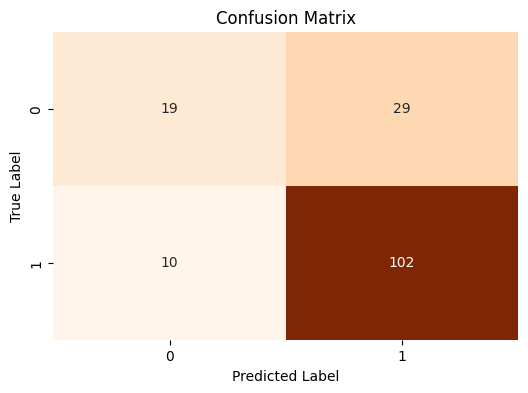

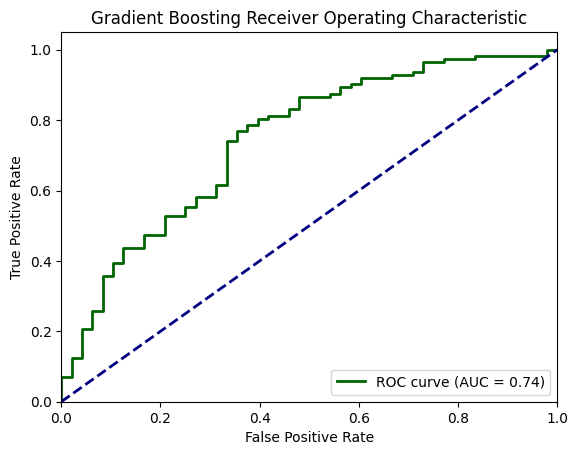

In [37]:
# Plotting the confusion matrix for Gradient Boosting
best_gb_classifier = GradientBoostingClassifier(random_state=42, **grid_search_gb.best_params_)
best_gb_classifier.fit(X_train_split, y_train_split)
y_val_pred_gb = best_gb_classifier.predict(X_val_split)
gb_best_hyperparameters = grid_search_gb.best_params_
cm_gb = create_and_plot_confusion_matrix(y_val_split, y_val_pred_gb, 'Gradient Boosting', 'Oranges')

# Plotting the ROC curve
y_val_prob_gb = best_gb_classifier.predict_proba(X_val_split)[:, 1]
create_roc_curve('Gradient Boosting', y_val_prob_gb, y_val_split, 'darkgreen')

### 2.4 -  Applying Bayes classifier:

In [38]:
# Applying Bayes classifier: 
gnb_classifier = GaussianNB()
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_gnb = cross_val_score(gnb_classifier, X_train_split, y_train_split, cv=kf, scoring='accuracy')

print(f"Gaussian Naive Bayes Cross-validation accuracy scores: {cv_scores_gnb}")
print(f"Mean cross-validation accuracy: {cv_scores_gnb.mean()}")
accuracy_gnb = cv_scores_gnb.mean()

Gaussian Naive Bayes Cross-validation accuracy scores: [0.75      0.671875  0.7265625 0.6484375 0.640625 ]
Mean cross-validation accuracy: 0.6875


In [39]:
# Grid search and hyperparameter tuning to GaussianNB
param_grid={'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
grid_search_gnb = GridSearchCV(estimator=gnb_classifier, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search_gnb.fit(X_train_split, y_train_split)

# Output the best parameters and best score
print("Best parameters found: ", grid_search_gnb.best_params_)
print("Best cross-validation score: ", grid_search_gnb.best_score_)

Best parameters found:  {'var_smoothing': 1e-08}
Best cross-validation score:  0.73125


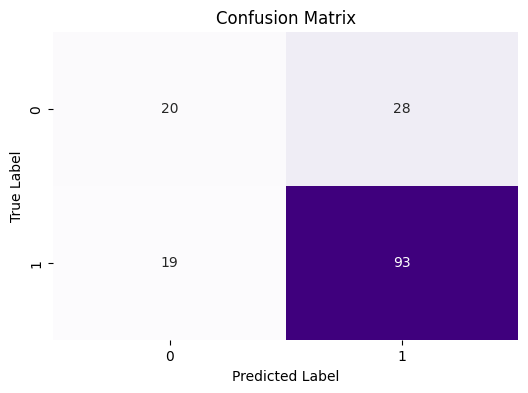

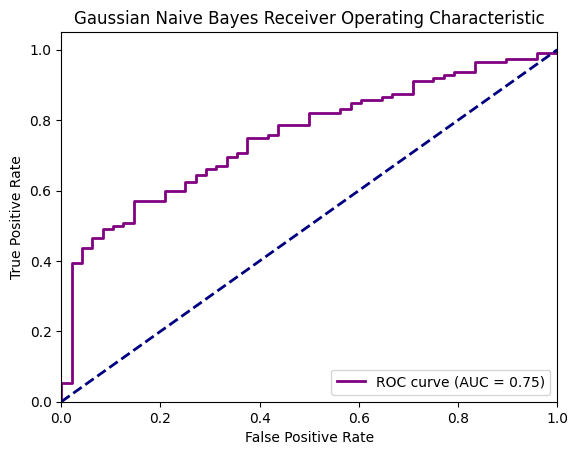

In [40]:
# Confusion matrix for Gaussian Naive Bayes with the best hyperparameter:
best_gnb_classifier = GaussianNB(var_smoothing=grid_search_gnb.best_params_['var_smoothing'])
best_gnb_classifier.fit(X_train_split, y_train_split)
y_val_pred_gnb = best_gnb_classifier.predict(X_val_split)
gnb_best_hyperparameters = grid_search_gnb.best_params_
cm_gnb = create_and_plot_confusion_matrix(y_val_split, y_val_pred_gnb, 'Gaussian Naive Bayes', 'Purples')

# Creating the ROC curve:
y_val_prob_gnb = best_gnb_classifier.predict_proba(X_val_split)[:, 1]
create_roc_curve('Gaussian Naive Bayes', y_val_prob_gnb, y_val_split, 'purple')

### 2.5 - Applying SVM classifier:

In [75]:
# Applying SVM classifier: 
svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=42))
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_svm = cross_val_score(svm_pipeline, X_train_split, y_train_split, cv=kf, scoring='accuracy')

print(f"Support Vector Machine Cross-validation accuracy scores: {cv_scores_svm}")
print(f"Mean cross-validation accuracy: {cv_scores_svm.mean()}")
accuracy_svm = cv_scores_svm.mean()

Support Vector Machine Cross-validation accuracy scores: [0.703125  0.703125  0.7578125 0.7109375 0.75     ]
Mean cross-validation accuracy: 0.725


In [76]:
# Set up the grid search
param_grid_svm = {
    'svc__C': [0.1, 1, 10, 100], 
    'svc__gamma': [0.001, 0.01, 0.1, 1]
}

grid_search_svm = GridSearchCV(estimator=svm_pipeline, param_grid=param_grid_svm, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search_svm.fit(X_train_split, y_train_split)

# Output the best parameters and best score
print("\nBest parameters found for SVC: ", grid_search_svm.best_params_)
print("Best cross-validation score: ", grid_search_svm.best_score_)


Best parameters found for SVC:  {'svc__C': 100, 'svc__gamma': 0.001}
Best cross-validation score:  0.728125


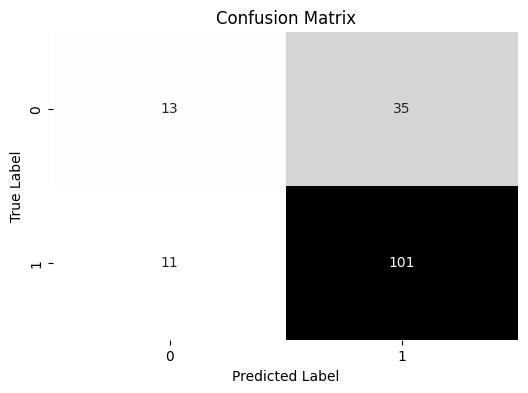

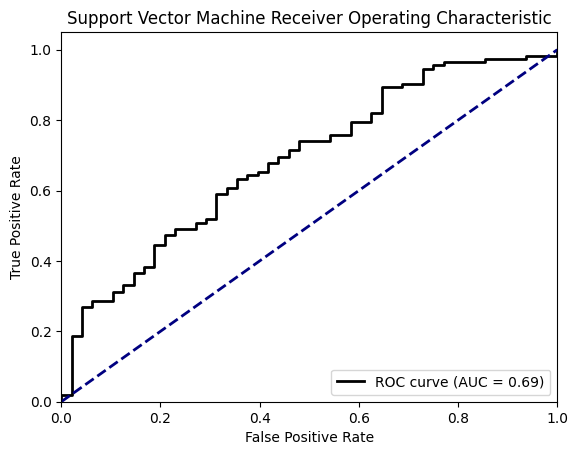

In [77]:
# Scaling the data
scaler = StandardScaler()
X_train_split_scaled = scaler.fit_transform(X_train_split)
X_val_split_scaled = scaler.transform(X_val_split)

best_C = grid_search_svm.best_params_['svc__C']
best_gamma = grid_search_svm.best_params_['svc__gamma']

# Plotting the confusion matrix for SVM
best_svc_classifier = SVC(C=best_C, gamma=best_gamma, kernel='rbf', random_state=42, probability=True)
best_svc_classifier.fit(X_train_split_scaled, y_train_split)
y_val_pred_svc = best_svc_classifier.predict(X_val_split_scaled)
svc_best_hyperparameters = grid_search_svm.best_params_
cm_svm = create_and_plot_confusion_matrix(y_val_split, y_val_pred_svc, 'Support Vector Machine', 'Greys')

# Creating the ROC curve:
y_val_prob_svc = best_svc_classifier.predict_proba(X_val_split_scaled)[:, 1]
create_roc_curve('Support Vector Machine', y_val_prob_svc, y_val_split, 'black')

### 2.6 - Applying Voting classifier:

In [82]:
# Using Voting Classifier with cross-validation to test the results:
estimators = [
    ('Random Forest', best_rf_classifier),
    ('Gradient Boosting', best_gb_classifier),
    ('Support Vector Machine', grid_search_svm.best_estimator_)
]

voting_classifier = VotingClassifier(estimators=estimators, voting='soft')
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_voting = cross_val_score(voting_classifier, X_train_split, y_train_split, cv=kf, scoring='accuracy')

print(f"Voting Classifier Cross-validation accuracy scores: {cv_scores_voting}")
print(f"Mean cross-validation accuracy: {cv_scores_voting.mean()}")
accuracy_voting = cv_scores_voting.mean()

Voting Classifier Cross-validation accuracy scores: [0.7578125 0.7578125 0.7734375 0.6875    0.765625 ]
Mean cross-validation accuracy: 0.7484375


In [83]:
# Set up the grid search
from itertools import product
weights_options = [1, 2, 3]
param_grid_vot = {'weights': list(product(weights_options, repeat=len(estimators)))}

grid_search_weights = GridSearchCV(estimator=voting_classifier, param_grid=param_grid_vot, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search_weights.fit(X_train_split, y_train_split)

# Output the best weights
print("Best weights found: ", grid_search_weights.best_params_['weights'])
print("Best cross-validation score with tuned weights:", grid_search_weights.best_score_)

Best weights found:  (2, 3, 1)
Best cross-validation score with tuned weights: 0.75625


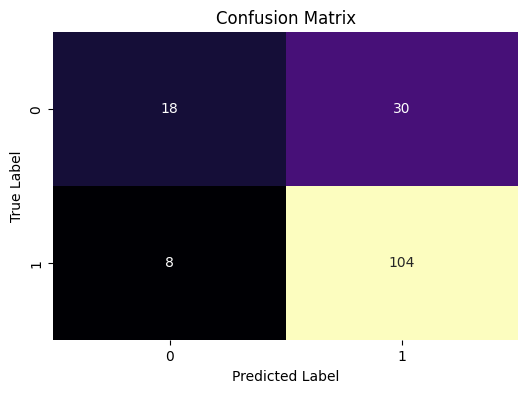

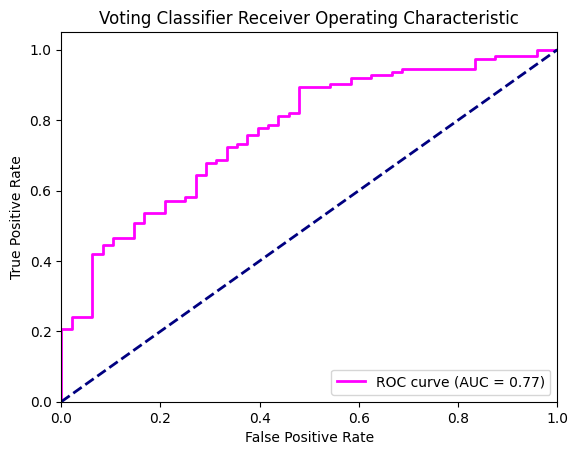

In [84]:
# Confusion matrix for Voting Classifier with the best hyperparameters
best_weights_voting = grid_search_weights.best_params_['weights']
best_voting_classifier = VotingClassifier(estimators=estimators, voting='soft', weights=best_weights_voting)
best_voting_classifier.fit(X_train_split, y_train_split)
y_val_pred_voting = best_voting_classifier.predict(X_val_split)
cm_voting = create_and_plot_confusion_matrix(y_val_split, y_val_pred_voting, 'Voting Classifier', 'magma')

# Creating the ROC curve:
y_val_prob_voting = best_voting_classifier.predict_proba(X_val_split)[:, 1]
create_roc_curve('Voting Classifier', y_val_prob_voting, y_val_split, 'magenta')

# 3 - Analysing the ROC curve, AUC, and Confusion matrix for each model:

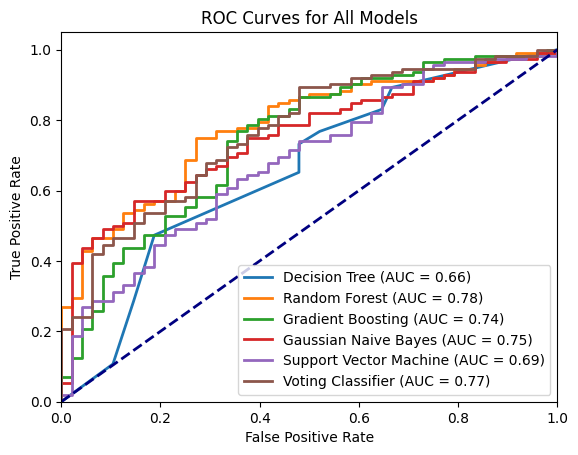

In [85]:
# Plotting the ROC for all models together
plt.figure()
# Decision Tree
y_val_prob_dt = best_dt_classifier.predict_proba(X_val_split)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_val_split, y_val_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
# Random Forest
y_val_prob_rf = best_rf_classifier.predict_proba(X_val_split)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val_split, y_val_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
# Gradient Boosting
y_val_prob_gb = best_gb_classifier.predict_proba(X_val_split)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_val_split, y_val_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, lw=2, label=f'Gradient Boosting (AUC = {roc_auc_gb:.2f})')
# Gaussian Naive Bayes
y_val_prob_gnb = best_gnb_classifier.predict_proba(X_val_split)[:, 1]
fpr_gnb, tpr_gnb, _ = roc_curve(y_val_split, y_val_prob_gnb)
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)
plt.plot(fpr_gnb, tpr_gnb, lw=2, label=f'Gaussian Naive Bayes (AUC = {roc_auc_gnb:.2f})')
# Support Vector Machine
y_val_prob_svc = best_svc_classifier.predict_proba(X_val_split_scaled)[:, 1]
fpr_svc, tpr_svc, _ = roc_curve(y_val_split, y_val_prob_svc)
roc_auc_svc = auc(fpr_svc, tpr_svc)
plt.plot(fpr_svc, tpr_svc, lw=2, label=f'Support Vector Machine (AUC = {roc_auc_svc:.2f})')
# Voting Classifier
y_val_prob_voting = best_voting_classifier.predict_proba(X_val_split)[:, 1]
fpr_voting, tpr_voting, _ = roc_curve(y_val_split, y_val_prob_voting)
roc_auc_voting = auc(fpr_voting, tpr_voting)
plt.plot(fpr_voting, tpr_voting, lw=2, label=f'Voting Classifier (AUC = {roc_auc_voting:.2f})')
# Plot settings
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.savefig('results/all_models_roc_curve.png')
plt.show()

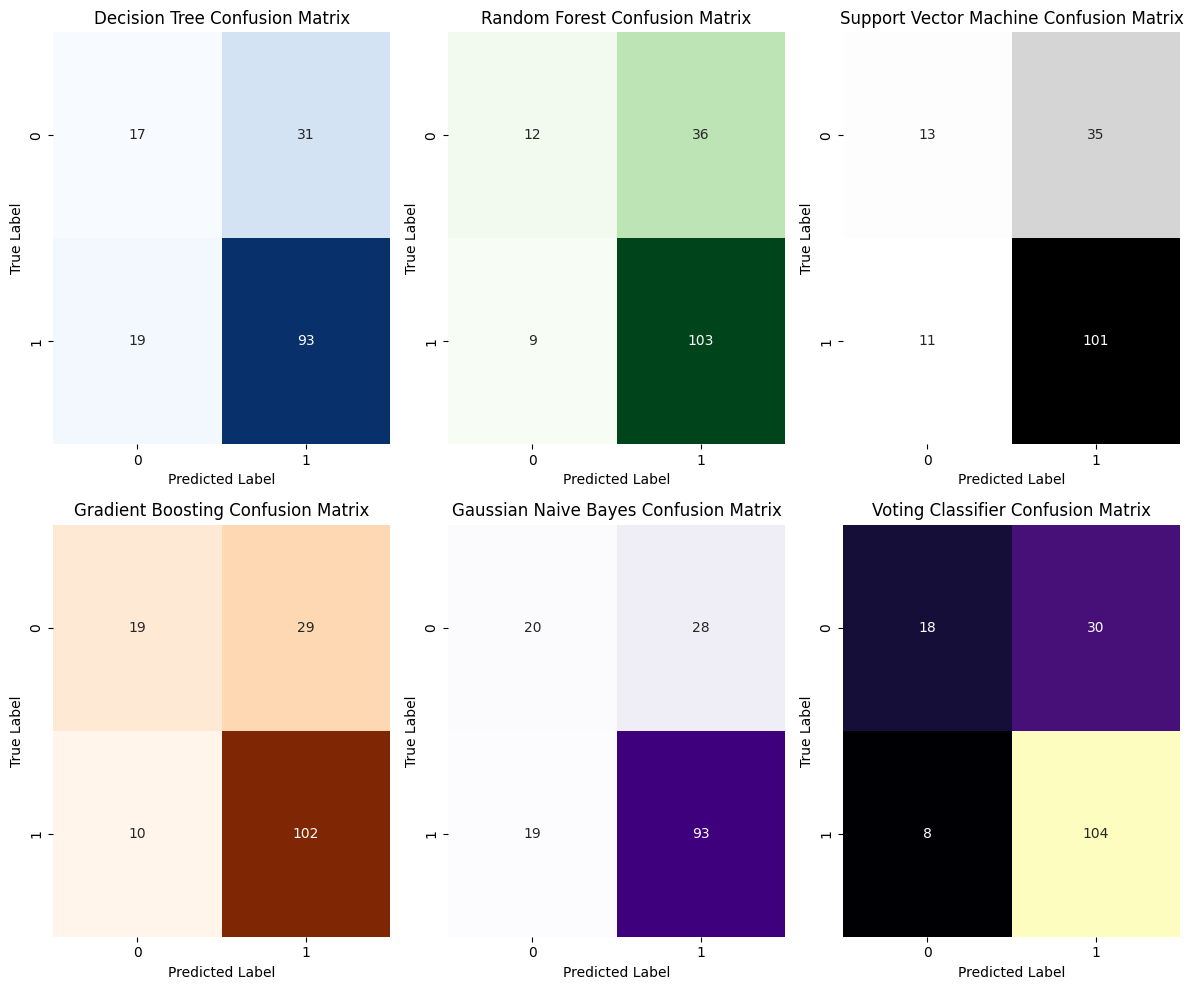

In [86]:
# Plotting all confusion matrices together
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
# Decision Tree
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_title('Decision Tree Confusion Matrix')
# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0, 1])
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_title('Random Forest Confusion Matrix')
# Gradient Boosting
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_title('Gradient Boosting Confusion Matrix')
# Gaussian Naive Bayes
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_title('Gaussian Naive Bayes Confusion Matrix')
# Support Vector Machine
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greys', cbar=False, ax=axes[0, 2])
axes[0, 2].set_xlabel('Predicted Label')
axes[0, 2].set_ylabel('True Label')
axes[0, 2].set_title('Support Vector Machine Confusion Matrix')
# Voting Classifier
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='magma', cbar=False, ax=axes[1, 2])
axes[1, 2].set_xlabel('Predicted Label')
axes[1, 2].set_ylabel('True Label')
axes[1, 2].set_title('Voting Classifier Confusion Matrix')
plt.tight_layout()
plt.savefig('results/all_models_confusion_matrices.png')
plt.show()

In [87]:
# Creating a table with the best hyperparameters and accuracies of each model
results_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'Gaussian Naive Bayes', 'Support Vector Machine', 'Voting Classifier'],
    'Best Hyperparameters': [dt_best_hyperparameters, rf_best_hyperparameters, gb_best_hyperparameters, gnb_best_hyperparameters, svc_best_hyperparameters, best_weights_voting],
    'Mean Cross-Validation Accuracy': [accuracy_dt, accuracy_rf, accuracy_gb, accuracy_gnb, accuracy_svm, accuracy_voting]
})
results_summary

,Model,Best Hyperparameters,Mean Cross-Validation Accuracy
0,Decision Tree,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.671875
1,Random Forest,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.740625
2,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 20, 'min_...",0.737500
3,Gaussian Naive Bayes,{'var_smoothing': 1e-08},0.687500
4,Support Vector Machine,"{'svc__C': 100, 'svc__gamma': 0.001}",0.725000
5,Voting Classifier,"(2, 3, 1)",0.748437


# 4 - Processing the test file and generating output:

### 4.1 - Opening the file an reading it, and making a general analysis.

In [88]:
df_test= pd.read_csv(os.path.join(folder_data, 'df_test.csv'))
df_test.head()

,id,garden_points_status,commitment_months,participation_history,project_focus_code,requested_resources_value,personal_reserve_status,volunteer_tenure_bracket,time_commitment_rate,household_profile,...,years_in_neighborhood_bracket,asset_contribution_type,member_age,other_support_plans,housing_situation,existing_commitments_count,role_skill_tier,dependents_supported,has_phone,newcomer_status
0,31,Points 0–199,18.0,Previous roles completed,Microenterprise support,1913.0,Reserve: ≥1000,<1,3.0,Committed/shared household,...,3.0,Community plot share,36.0,Partner bank,Own housing,1.0,Skilled volunteer,1.0,Has phone,Newcomer
1,129,Points 0–199,12.0,Issues on prior roles,Transport (used),1860.0,Reserve: <100,unemployed,4.0,Single adult,...,2.0,Shared tools,34.0,NaN,Own housing,2.0,Highly skilled / lead,1.0,Has phone,Newcomer
2,290,Points negative,24.0,Delayed in prior commitments,Communications equipment,1024.0,Reserve: <100,<1,4.0,Committed/shared household,...,4.0,Community plot share,48.0,Partner stores,Own housing,1.0,Skilled volunteer,1.0,No phone,Newcomer
3,217,Points negative,18.0,No prior roles / all on time,Microenterprise support,3104.0,Reserve: <100,4<=X<7,3.0,Single adult,...,1.0,Long-term fund,31.0,Partner bank,Own housing,1.0,Skilled volunteer,1.0,Has phone,Newcomer
4,967,Points 0–199,27.0,Issues on prior roles,Communications equipment,2520.0,Reserve: 500–999,1<=X<4,4.0,Single adult,...,2.0,Long-term fund,23.0,NaN,Own housing,2.0,Unskilled resident,1.0,No phone,Newcomer


In [89]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             200 non-null    int64  
 1   garden_points_status           200 non-null    object 
 2   commitment_months              200 non-null    float64
 3   participation_history          200 non-null    object 
 4   project_focus_code             200 non-null    object 
 5   requested_resources_value      200 non-null    float64
 6   personal_reserve_status        200 non-null    object 
 7   volunteer_tenure_bracket       200 non-null    object 
 8   time_commitment_rate           200 non-null    float64
 9   household_profile              200 non-null    object 
 10  co_sponsor_presence            200 non-null    object 
 11  years_in_neighborhood_bracket  200 non-null    float64
 12  asset_contribution_type        200 non-null    obj

In [90]:
# Counting the number of NaN values in each column of the test dataset
for column in df_test.columns:
    num_missing = df_test[column].isna().sum()
    print(f"Column '{column}' has {num_missing} missing values.")

Column 'id' has 0 missing values.
Column 'garden_points_status' has 0 missing values.
Column 'commitment_months' has 0 missing values.
Column 'participation_history' has 0 missing values.
Column 'project_focus_code' has 0 missing values.
Column 'requested_resources_value' has 0 missing values.
Column 'personal_reserve_status' has 0 missing values.
Column 'volunteer_tenure_bracket' has 0 missing values.
Column 'time_commitment_rate' has 0 missing values.
Column 'household_profile' has 0 missing values.
Column 'co_sponsor_presence' has 0 missing values.
Column 'years_in_neighborhood_bracket' has 0 missing values.
Column 'asset_contribution_type' has 0 missing values.
Column 'member_age' has 0 missing values.
Column 'other_support_plans' has 165 missing values.
Column 'housing_situation' has 0 missing values.
Column 'existing_commitments_count' has 0 missing values.
Column 'role_skill_tier' has 0 missing values.
Column 'dependents_supported' has 0 missing values.
Column 'has_phone' has 0 

### 4.2 - Removing the column with a high number of NaN:

In [91]:
# Removing the column other_support_plans due to high number of missing values (649/800)=~81%
df_test = df_test.drop(columns=['other_support_plans'])

### 4.3 - Transforming the categories columns into useful information:

In [92]:
# Identifying categorical and numerical columns
categorical_cols = df_test.select_dtypes(include=['object']).columns
numerical_cols = df_test.select_dtypes(include=[np.number]).columns
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Categorical columns: Index(['garden_points_status', 'participation_history', 'project_focus_code',
       'personal_reserve_status', 'volunteer_tenure_bracket',
       'household_profile', 'co_sponsor_presence', 'asset_contribution_type',
       'housing_situation', 'role_skill_tier', 'has_phone', 'newcomer_status'],
      dtype='object')
Numerical columns: Index(['id', 'commitment_months', 'requested_resources_value',
       'time_commitment_rate', 'years_in_neighborhood_bracket', 'member_age',
       'existing_commitments_count', 'dependents_supported'],
      dtype='object')


In [93]:
# counting the number of categories for each categorical column
for col in categorical_cols:
    num_categories = df_test[col].nunique()
    print(f"Column '{col}' has {num_categories} unique categories.")
    print(f"The categories are: {df_test[col].unique()}\n")

Column 'garden_points_status' has 4 unique categories.
The categories are: ['Points 0–199' 'Points negative' 'No points account' 'Points 200+']

Column 'participation_history' has 5 unique categories.
The categories are: ['Previous roles completed' 'Issues on prior roles'
 'Delayed in prior commitments' 'No prior roles / all on time'
 'All roles on time']

Column 'project_focus_code' has 10 unique categories.
The categories are: ['Microenterprise support' 'Transport (used)' 'Communications equipment'
 'Workshop equipment' 'Transport (new)' 'Plot repairs' 'Other project'
 'Retraining' 'Training / education' 'Shared appliances']

Column 'personal_reserve_status' has 5 unique categories.
The categories are: ['Reserve: ≥1000' 'Reserve: <100' 'Reserve: 500–999' 'Reserve: 100–499'
 'No reserve']

Column 'volunteer_tenure_bracket' has 5 unique categories.
The categories are: ['<1' 'unemployed' '4<=X<7' '1<=X<4' '>=7']

Column 'household_profile' has 4 unique categories.
The categories are: ['

In [94]:
ordinal_cols = [
    'garden_points_status', 
    'personal_reserve_status', 
    'role_skill_tier'
]

# Define the specific order for each feature
garden_points_categories = ['Points negative', 'No points account', 'Points 0–199', 'Points 200+']
personal_reserve_categories = ['No reserve', 'Reserve: <100', 'Reserve: 100–499', 'Reserve: 500–999', 'Reserve: ≥1000']
role_skill_categories = ['Unemployed / non-resident unskilled', 'Unskilled resident', 'Skilled volunteer', 'Highly skilled / lead']
# 2. Define your nominal (one-hot) features
# All remaining 'object' columns that are not ordinal
nominal_cols = [
    'participation_history', 'project_focus_code', 'volunteer_tenure_bracket', 
    'household_profile', 'co_sponsor_presence', 'asset_contribution_type',
    'housing_situation', 'has_phone', 'newcomer_status'
]

# 3. Define your numerical features (remove 'id')
numerical_cols = [
    'commitment_months', 'requested_resources_value', 'time_commitment_rate', 
    'years_in_neighborhood_bracket', 'member_age', 'existing_commitments_count', 
    'dependents_supported'
]

In [95]:
df_test.drop(columns=['id'], inplace=True)


In [96]:
# 4. Create the ColumnTransformer
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[
            garden_points_categories, 
            personal_reserve_categories, 
            role_skill_categories
        ]), ordinal_cols),
        
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        
        ('numeric', 'passthrough', numerical_cols)
    ],
    remainder='drop' # Drops the 'id' column and any others not specified
)

In [97]:
# 5. Apply the new preprocessing
x_test_processed = preprocessor_tree.fit_transform(df_test)

ohe_feature_names = preprocessor_tree.named_transformers_['onehot'].get_feature_names_out(nominal_cols)
all_feature_names = ordinal_cols + list(ohe_feature_names) + numerical_cols

# Create the processed DataFrame
df_test_encoded = pd.DataFrame(x_test_processed, columns=all_feature_names, index=df_test.index)

print("New processed test data shape:", df_test_encoded.shape)
df_test_encoded.head()

New processed test data shape: (200, 48)


,garden_points_status,personal_reserve_status,role_skill_tier,participation_history_All roles on time,participation_history_Delayed in prior commitments,participation_history_Issues on prior roles,participation_history_No prior roles / all on time,participation_history_Previous roles completed,project_focus_code_Communications equipment,project_focus_code_Microenterprise support,...,has_phone_No phone,newcomer_status_Local resident,newcomer_status_Newcomer,commitment_months,requested_resources_value,time_commitment_rate,years_in_neighborhood_bracket,member_age,existing_commitments_count,dependents_supported
0,2.0,4.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,18.0,1913.0,3.0,3.0,36.0,1.0,1.0
1,2.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,12.0,1860.0,4.0,2.0,34.0,2.0,1.0
2,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,24.0,1024.0,4.0,4.0,48.0,1.0,1.0
3,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,18.0,3104.0,3.0,1.0,31.0,1.0,1.0
4,2.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,27.0,2520.0,4.0,2.0,23.0,2.0,1.0


In [98]:
# verifying if there's a categorical
for col in df_test_encoded.columns:
    if df_test_encoded[col].dtype == 'object':
        print(f"Categorical column found: {col}")

In [104]:
# Applying our best model (Voting Classifier) to the test dataset
y_test_pred_voting = best_voting_classifier.predict(df_test_encoded)

In [105]:
# Verifying the balance of the predictions in percentage for each class:
unique, counts = np.unique(y_test_pred_voting, return_counts=True)
prediction_balance = dict(zip(unique, counts))
total = len(y_test_pred_voting)
prediction_pct = {k: (v / total) * 100 for k, v in prediction_balance.items()}

print("Prediction balance (percentage) per class:")
for cls, pct in sorted(prediction_pct.items()):
    print(f"  Class {cls}: {pct:.2f}% ({prediction_balance[cls]} / {total})")

Prediction balance (percentage) per class:
  Class 0: 19.50% (39 / 200)
  Class 1: 80.50% (161 / 200)


In [106]:
# Converting to a dataset .csv that will have 2 columns: id and y_pred
submission_df = pd.DataFrame({
    'id': pd.read_csv(os.path.join(folder_data, 'df_test.csv'))['id'],
    'y_pred': np.where(y_test_pred_voting == 1, 'good', 'bad')
})
submission_df.to_csv('results/predicoes_tp_final.csv', index=False)  